Train accuracy: 0.9760
Validation accuracy: 0.9614
Top 15 Features and Their Importance:
                          feature  importance       std
20                    p_deltaEta1    0.025306  0.000946
2                          p_Rhad    0.019308  0.000755
68                    pX_etcone20    0.017456  0.000502
36                  pX_E_Lr1_MedG    0.013872  0.000458
9                        p_TRTPID    0.012203  0.000683
18                      p_sigmad0    0.010286  0.000577
128                   pX_E5x7_Lr2    0.008425  0.000384
132                  pX_E7x11_Lr2    0.007097  0.000556
62                        pX_e132    0.006667  0.000341
30                    pX_E7x7_Lr2    0.006361  0.000478
115                       pX_e233    0.006319  0.000328
10   p_numberOfInnermostPixelHits    0.006128  0.000350
69                    pX_etcone30    0.006092  0.000504
61                       pX_e1152    0.005306  0.000350
34                   pX_E_Lr1_HiG    0.005036  0.000309


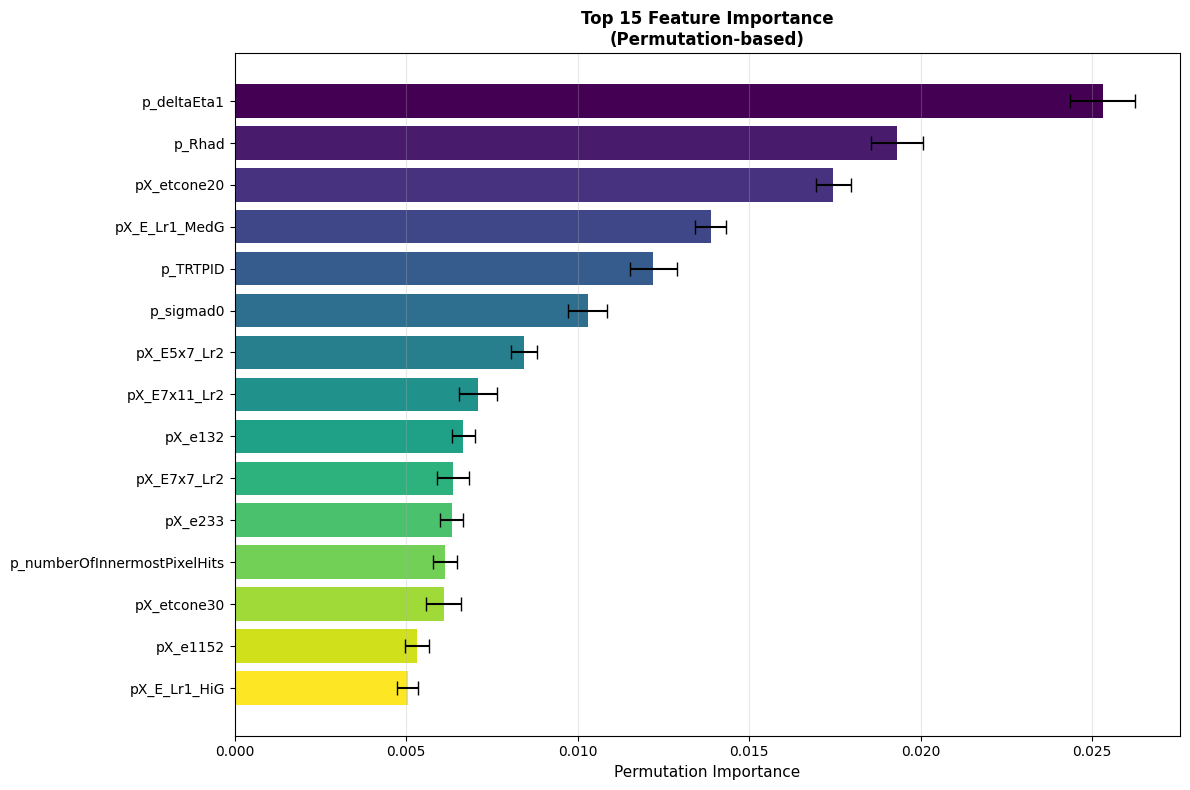

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


torch.set_num_threads(os.cpu_count() or 1)
torch.set_num_interop_threads(1)

# PyTorch MLP wrapped as sklearn-compatible classifier
class PyTorchNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_size=64, dropout=0.2, learning_rate=0.001, epochs=50, batch_size=32, random_state=42):
        self.hidden_size = hidden_size
        self.dropout = dropout
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.model = None
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    def _build_model(self, input_dim):
        return nn.Sequential(
            nn.Linear(input_dim, self.hidden_size),
            nn.ReLU(),
            nn.Dropout(self.dropout),
            nn.Linear(self.hidden_size, self.hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(self.dropout),
            nn.Linear(self.hidden_size // 2, 1),
            nn.Sigmoid()
        ).to(self.device)
    
    def fit(self, X, y):
        torch.manual_seed(self.random_state)
        X_tensor = torch.FloatTensor(X.values if hasattr(X, 'values') else X).to(self.device)
        y_tensor = torch.FloatTensor(y.values if hasattr(y, 'values') else y).reshape(-1, 1).to(self.device)
        
        if self.model is None:
            self.model = self._build_model(X_tensor.shape[1])
        
        optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        criterion = nn.BCELoss()
        
        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        self.model.train()
        for _ in range(self.epochs):
            for X_batch, y_batch in loader:
                optimizer.zero_grad()
                output = self.model(X_batch)
                loss = criterion(output, y_batch)
                loss.backward()
                optimizer.step()
        
        return self
    
    def predict_proba(self, X):
        X_tensor = torch.FloatTensor(X.values if hasattr(X, 'values') else X).to(self.device)
        self.model.eval()
        with torch.no_grad():
            proba_class1 = self.model(X_tensor).cpu().numpy().flatten()
        proba_class0 = 1 - proba_class1
        return np.column_stack([proba_class0, proba_class1])
    
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] > 0.5).astype(int)
    
    def score(self, X, y):
        y_pred = self.predict(X)
        y_true = y.values if hasattr(y, 'values') else y
        return np.mean(y_pred == y_true)


# Load data
class_train_data = pd.read_csv('../Data/AppML_InitialProject_train.csv')
class_test_data = pd.read_csv('../Data/AppML_InitialProject_test_classification.csv')

# Prepare features and target
target = class_train_data['p_Truth_isElectron']
variables = class_train_data.drop(columns=['p_Truth_isElectron', 'p_Truth_Energy'])

# Normalize features
scaler = StandardScaler()
variables_scaled = pd.DataFrame(
    scaler.fit_transform(variables),
    columns=variables.columns,
    index=variables.index
)

# Split into train/validation for calculating importance on unseen data
X_train, X_val, y_train, y_val = train_test_split(
    variables_scaled, target, test_size=0.2, random_state=42, stratify=target
)

# Train PyTorch model
model = PyTorchNNClassifier(
    hidden_size=128,
    dropout=0.1,
    learning_rate=0.005,
    epochs=300,
    batch_size=32,
    random_state=42
)

model.fit(X_train, y_train)

# Evaluate on validation set
train_score = model.score(X_train, y_train)
val_score = model.score(X_val, y_val)
print(f'Train accuracy: {train_score:.4f}')
print(f'Validation accuracy: {val_score:.4f}')

# Calculate permutation importance on validation set
perm_importance = permutation_importance(
    model, X_val, y_val,
    n_repeats = 10,
    random_state = 42,
    n_jobs = -1
)

# Create results dataframe
importance_df = pd.DataFrame({
    'feature': variables.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

# Bar plot
top_n = 15
top_features = importance_df.head(top_n)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
plt.figure(figsize=(12, 8))
plt.barh(top_features['feature'], top_features['importance'], 
         xerr=top_features['std'], color=colors, capsize=5)
plt.xlabel('Permutation Importance', fontsize=11)
plt.title(f'Top {top_n} Feature Importance\n(Permutation-based)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

#Print top 15 features and their importance
print("Top 15 Features and Their Importance:")
print(importance_df.head(15))

In [4]:
print("Top 15 Features and Their Importance:")
print(importance_df.head(15))

Top 15 Features and Their Importance:
                           feature  importance  std
0   averageInteractionsPerCrossing         0.0  0.0
1                          p_Rhad1         0.0  0.0
2                           p_Rhad         0.0  0.0
3                             p_f3         0.0  0.0
4                          p_weta2         0.0  0.0
5                           p_Rphi         0.0  0.0
6                           p_Reta         0.0  0.0
7                         p_Eratio         0.0  0.0
8                             p_f1         0.0  0.0
9                         p_TRTPID         0.0  0.0
10    p_numberOfInnermostPixelHits         0.0  0.0
11             p_numberOfPixelHits         0.0  0.0
12               p_numberOfSCTHits         0.0  0.0
13               p_numberOfTRTHits         0.0  0.0
14             p_TRTTrackOccupancy         0.0  0.0


In [ ]:
# Retrain with top features
top_feature_names = top_features['feature'].tolist()
X_train_top = X_train[top_feature_names]
X_val_top = X_val[top_feature_names]

model_top = PyTorchNNClassifier(
    hidden_size=128,
    dropout=0.1,
    learning_rate=0.005,
    epochs=300,
    batch_size=32,
    random_state=42
)

model_top.fit(X_train_top, y_train)
train_score_top = model_top.score(X_train_top, y_train)
val_score_top = model_top.score(X_val_top, y_val)

print(f'Train accuracy with top features: {train_score_top:.4f}')
print(f'Validation accuracy with top features: {val_score_top:.4f}')

Train accuracy with top features: 0.9428
Validation accuracy with top features: 0.9422


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Hyperparameter tuning for PyTorch NN on the reduced 15-feature set
param_distributions = {
    'hidden_size': randint(64, 256),
    'dropout': uniform(0.1, 0.4),
    'learning_rate': uniform(0.0001, 0.01),
    'epochs': randint(30, 100),
    'batch_size': [16, 32, 64]
}

random_search = RandomizedSearchCV(
    estimator=PyTorchNNClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_top, y_train)

print(f'Best CV score: {random_search.best_score_:.4f}')
print(f'Best parameters: {random_search.best_params_}')

best_model = random_search.best_estimator_
val_score_tuned = best_model.score(X_val_top, y_val)
print(f'Validation accuracy after tuning: {val_score_tuned:.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits


KeyboardInterrupt: 

In [ ]:
from pathlib import Path

# Load test data, normalize with the training scaler, and extract top features
test_data_raw = pd.read_csv('../Data/AppML_InitialProject_test_classification.csv')
test_data_scaled = pd.DataFrame(
    scaler.transform(test_data_raw),
    columns=test_data_raw.columns
)
X_test = test_data_scaled[top_feature_names]

# Get probability predictions for class 1 (electron)
test_predictions = best_model.predict_proba(X_test)[:, 1]

# Define output paths and filenames
solution_name = "PyTorch"
name = "BenjaminSiddique"
output_dir = Path('../Classification/Output')
output_dir.mkdir(exist_ok=True)

# Export predictions
predictions_filename = f"Classification_{name}_{solution_name}.csv"
predictions_filepath = output_dir / predictions_filename
with open(predictions_filepath, 'w') as f:
    for idx, pred in enumerate(test_predictions):
        f.write(f"{idx},{pred:.6f}\n")

#Export chosen features
varlist_filename = f"Classification_{name}_{solution_name}_VariableList.csv"
varlist_filepath = output_dir / varlist_filename
with open(varlist_filepath, 'w') as f:
    for var in top_feature_names:
        f.write(f"{var}\n")

In [ ]:
import sys, subprocess

returncode = subprocess.run([sys.executable, "../SubmissionChecker.py", str(output_dir.resolve())])

if returncode.returncode == 0:
    print("\n✓ Submission files passed validation checks.")
else:
    print("\n✗ Submission files failed validation checks. Please review the output above for details.")


✓ Submission files passed validation checks.
